Parámetros óptimos (norm): w = 9.102397, b = -1.127252
NLL final (promedio): 0.450192


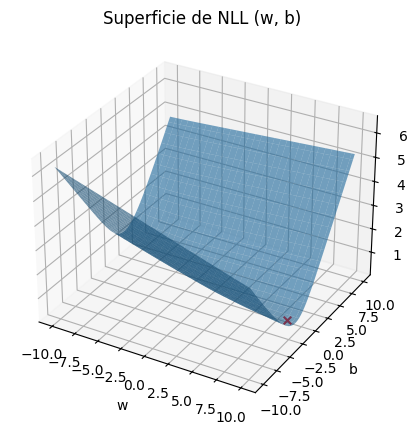

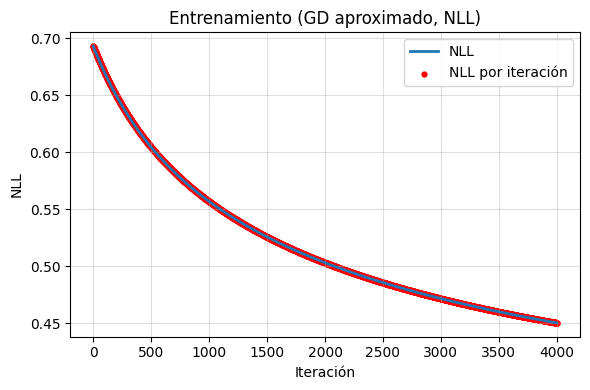

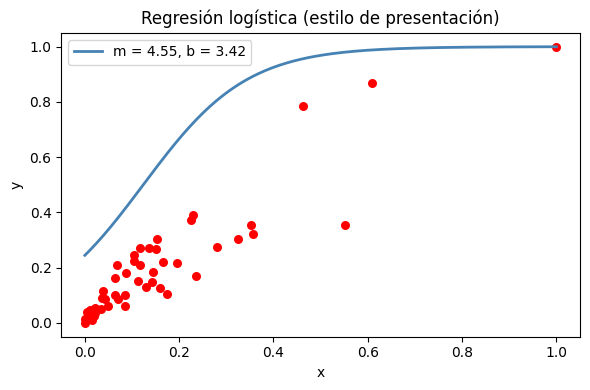

Best solution norm: 9.1023970393011577, -1.1272524909233805
Best fitness norm: 0.4501916771892026


In [17]:
#######################################################################################
# Práctica 5: Regresión LOGÍSTICA con GD "aproximado" usando Negative Log-Likelihood
# - Dataset: mismo URL que P2 (2 columnas numéricas)
#######################################################################################
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

# ==============================
# 1) Carga del dataset
# ==============================
url = "https://raw.githubusercontent.com/ChristianLuna1/tesis-maestria/refs/heads/main/Machine_Learning/DatosPractica1CLuna.csv"
df = pd.read_csv(url)

# X: 1ra columna (feature continua), y_cont: 2da columna (continua)
X_raw = df.iloc[:, 0].astype(float).values
y_cont = df.iloc[:, 1].astype(float).values

# Para regresión logística necesitamos etiquetas binarias.
# Usamos la mediana de la segunda columna como umbral para y ∈ {0,1}.
thr = np.median(y_cont)
y = (y_cont >= thr).astype(float)

# Normalización min–max de X para estabilidad
xmin, xmax = X_raw.min(), X_raw.max()
X = (X_raw - xmin) / (xmax - xmin)
n = X.size

# ==============================
# 2) Sigmoide y NLL estables
# ==============================
def sigmoid(z):
    zc = np.clip(z, -50, 50)
    return 1.0 / (1.0 + np.exp(-zc))

def softplus(t):
    tc = np.clip(t, -50, 50)
    # softplus(t) = log(1 + exp(t)) de forma estable
    return np.where(tc > 0, tc + np.log1p(np.exp(-tc)),
                           np.log1p(np.exp(tc)))

def nll(theta):
    """ Negative Log-Likelihood promedio para logística: mean(softplus(z) - y*z) """
    w, b = theta[0], theta[1]
    z = w * X + b
    return float(np.mean(softplus(z) - y * z))

# ==============================
# 3) Superficie NLL (w,b) para visualizar
# ==============================
wmin, wmax = -10.0, 10.0
bmin, bmax = -10.0, 10.0

Wg = np.linspace(wmin, wmax, 60)
Bg = np.linspace(bmin, bmax, 60)
Wm, Bm = np.meshgrid(Wg, Bg)
Z = np.zeros_like(Wm)

for i in range(Wm.shape[0]):
    for j in range(Wm.shape[1]):
        Z[i, j] = nll(np.array([Wm[i, j], Bm[i, j]]))

plt.ion()
fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111, projection='3d')
ax.set_xlabel('w'); ax.set_ylabel('b')
ax.set_title('Superficie de NLL (w, b)')
ax.plot_surface(Wm, Bm, Z, alpha=0.6)

# ==============================
# 4) GD aproximado (diferencia hacia adelante)
# ==============================
max_iter = 4000
alpha    = 0.1      # tasa de aprendizaje (como en P4 / compañero)
delta    = 1e-6     # paso para diferencias finitas
theta    = np.array([0.0, 0.0], dtype=float)  # [w, b]
best_theta = theta.copy()
best_loss  = nll(theta)
hist = [best_loss]

# punto inicial en la superficie
pt = ax.scatter([theta[0]], [theta[1]], [best_loss], c='red', s=30, marker="x")
fig.canvas.draw(); fig.canvas.flush_events(); time.sleep(1e-9)

for it in range(1, max_iter + 1):
    cur = nll(theta)

    # gradiente numérico (forward differences)
    grad = np.zeros_like(theta)
    for k in range(2):
        th = theta.copy()
        th[k] += delta
        grad[k] = (nll(th) - cur) / delta

    # paso GD
    theta = theta - alpha * grad

    # clipping suave para estabilidad/visualización
    theta[0] = np.clip(theta[0], wmin, wmax)
    theta[1] = np.clip(theta[1], bmin, bmax)

    loss = nll(theta)
    hist.append(loss)

    if loss < best_loss:
        best_loss = loss
        best_theta = theta.copy()

    # refresco visual ocasional
    if it % 50 == 0:
        pt.remove()
        pt = ax.scatter([theta[0]], [theta[1]], [loss], c='red', s=30, marker="x")
        fig.canvas.draw(); fig.canvas.flush_events()

    # criterios de paro simples
    if np.linalg.norm(grad) < 1e-8:
        print(f"[STOP] ||grad|| pequeño en iter {it}")
        break
    if len(hist) > 5 and abs(hist[-1] - hist[-5]) < 1e-12:
        print(f"[STOP] mejora muy pequeña en iter {it}")
        break

plt.ioff()

print(f"Parámetros óptimos (norm): w = {best_theta[0]:.6f}, b = {best_theta[1]:.6f}")
print(f"NLL final (promedio): {best_loss:.6f}")

# ==============================
# 5) Curva de entrenamiento
# ==============================
plt.figure(figsize=(6,4))
its = np.arange(len(hist))
plt.plot(its, hist, lw=2, label="NLL")
plt.scatter(its, hist, s=12, color='red', label="NLL por iteración")
plt.xlabel("Iteración"); plt.ylabel("NLL")
plt.title("Entrenamiento (GD aproximado, NLL)")
plt.grid(alpha=0.4); plt.legend(); plt.tight_layout()
plt.show()



m_disp = w_opt / 2.0
b_disp = b_opt + w_opt / 2.0

# Puntos rojos: segunda columna continua normalizada (solo estética)
y_plot = (y_cont - y_cont.min()) / (y_cont.max() - y_cont.min())

# Curva azul evaluada sobre x∈[0,1] pero usando la forma en x' = 2x - 1
x_grid = np.linspace(0.0, 1.0, 200)
p_grid = sigmoid(m_disp * (2.0 * x_grid - 1.0) + b_disp)

plt.figure(figsize=(6,4))
plt.scatter(X, y_plot, color='red', s=30)
plt.plot(x_grid, p_grid, color='steelblue', lw=2,
         label=f"m = {m_disp:.2f}, b = {b_disp:.2f}")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Regresión logística")
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

print(f"Best solution norm: {best_theta[0]:.16f}, {best_theta[1]:.16f}")
print(f"Best fitness norm: {best_loss:.16f}")

